# Machine Learning Lab 1 - Regression Models
## 1. Dataset and Initial Setup
This lab uses an air travel dataset containing information about flights, such as airline, route, flight duration, number of stops, travel class, and price.
The goal is to use these features to build regression models that can predict flight prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSVs
business_df = pd.read_csv('../data/business.csv')
economy_df = pd.read_csv('../data/economy.csv')

# Label cabin class
business_df['class'] = 'Business'
economy_df['class'] = 'Economy'

# Merge into one dataset & drop exact duplicates
df = pd.concat([business_df, economy_df], ignore_index=True)
df = df.drop_duplicates()

print(f"Total rows: {len(df):,}")
df.head()

Total rows: 300,259


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612",Business
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612",Business
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220",Business
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450",Business
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690",Business


## 2. Data Preprocessing
Before training the models, the dataset needs to be cleaned and transformed.
The price and flight duration are initially stored as text, so they must be converted into numerical values. The date is also converted into a datetime format so that the day of the week can be extracted.
These transformations make the data suitable for machine learning.

In [2]:
# 1. Clean price: remove commas like "25,612" -> 25612.0
df['price'] = df['price'].astype(str).str.replace(',', '').astype(float)

# 2. Parse time_taken ("02h 15m") into total minutes (135)
def parse_duration(val):
    val_str = str(val).strip()
    if 'h' in val_str:
        parts = val_str.split('h')
        hours = float(parts[0]) if parts[0] else 0.0
        min_part = parts[1].replace('m', '').strip()
        minutes = float(min_part) if min_part else 0.0
        return int(hours * 60 + minutes)
    return np.nan

df['duration_min'] = df['time_taken'].apply(parse_duration)

# 3. Extract day of week from date string
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['day_of_week'] = df['date'].dt.dayofweek

print("Missing values check:")
print(df.isnull().sum())

Missing values check:
date            0
airline         0
ch_code         0
num_code        0
dep_time        0
from            0
time_taken      0
stop            0
arr_time        0
to              0
price           0
class           0
duration_min    0
day_of_week     0
dtype: int64


## 3. Exploratory Data Analysis
Before building the regression models, we examine some relationships in the data.
The first plot compares flight prices between Business and Economy class.
The second plot investigates whether longer flights tend to have higher prices.
These visualizations help us understand the dataset and identify possible relationships between the features and the target variable.

In [3]:
# # Plot 1: Price difference between Business and Economy
# plt.figure(figsize=(8, 4))
# sns.boxplot(data=df, x='class', y='price')
# plt.title('Price Distribution by Class')
# plt.show()

# # Plot 2: Flight duration vs Price
# plt.figure(figsize=(8, 4))
# sns.scatterplot(data=df.sample(2000, random_state=42), x='duration_min', y='price', hue='class', alpha=0.5)
# plt.title('Flight Duration vs Price')
# plt.show()

## 4. Feature Selection and Encoding
The target variable is the flight price, which we want the models to predict.
The selected features describe the flight's airline, route, number of stops, travel class, duration, and day of the week.
Because machine learning models require numerical input, categorical variables such as airline and class are converted into dummy variables.


In [4]:
# Select features to keep for modeling
features = ['airline', 'from', 'to', 'stop', 'class', 'duration_min', 'day_of_week']
X = df[features]
y = df['price']  # Target variable

# Convert categorical text into binary dummy variables (0/1)
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original features shape:", X.shape)
print("Encoded features shape (all numeric):", X_encoded.shape)
X_encoded.head()

Original features shape: (300259, 7)
Encoded features shape (all numeric): (300259, 59)


,duration_min,day_of_week,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,airline_Trujet,airline_Vistara,from_Chennai,...,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia RPR\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Raipur\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Ranchi\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia STV\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Surat\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia VTZ\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Vishakhapatnam\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_2+-stop,stop_non-stop,class_Economy
0,120,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,135,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,1485,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1590,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,400,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 5. Train-Test Split
The dataset is divided into two parts:
- 80% is used for training the models.
- 20% is kept as unseen test data.


The test data is not used during training. This allows us to evaluate how well the models generalize to new observations. A fixed random state is used so that the same split can be reproduced.

In [5]:
from sklearn.model_selection import train_test_split

# Split into 80% train and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")

Training set size: 240,207 samples
Test set size: 60,052 samples


## 6. Regression Models
Two different regression models are trained and compared:

1. **Linear Regression** - a simple model that assumes a linear relationship between the features and the target.
2. **Random Forest Regression** - an ensemble model that can capture more complex, non-linear relationships.


Both models are trained using the same training data so that their performance can be compared fairly.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression trained successfully!")

# Model 2: Random Forest Regressor (using n_estimators=100 and n_jobs=-1 for faster execution)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

Linear Regression trained successfully!
Random Forest trained successfully!


## 7. Model Evaluation
The trained models are evaluated using the test data.

Three regression metrics are used:

- **MAE (Mean Absolute Error):** the average absolute difference between the predicted and actual prices. Lower is better.
- **RMSE (Root Mean Squared Error):** similar to MAE, but gives greater weight to large errors. Lower is better.
- **R² (R-squared):** measures how much of the variation in flight prices is explained by the model. Higher is better.

In [7]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Make predictions on the test set
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Calculate metrics for Linear Regression
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = root_mean_squared_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

# Calculate metrics for Random Forest
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = root_mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

# Display comparison summary
results_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': [lr_mae, lr_rmse, lr_r2],
    'Random Forest': [rf_mae, rf_rmse, rf_r2]
})

results_df

,Metric,Linear Regression,Random Forest
0,MAE,4881.631980,2750.561134
1,RMSE,7039.359927,4254.754939
2,R2 Score,0.903570,0.964772


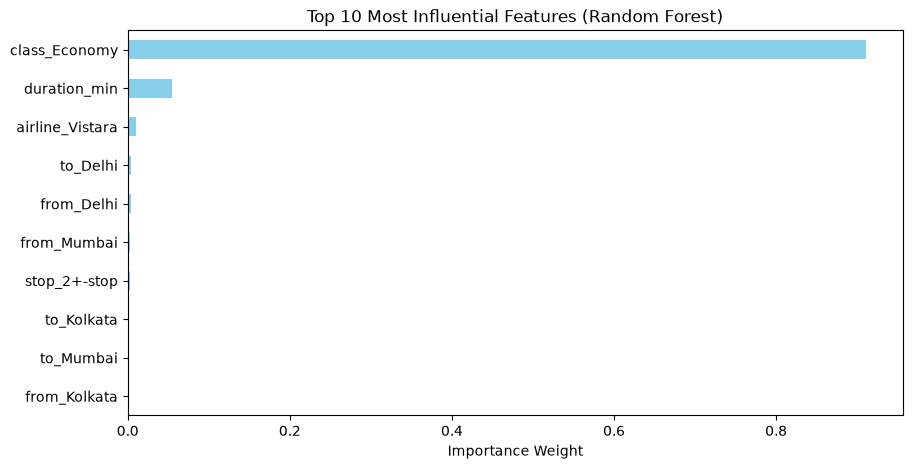

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)

# Plot top 10 most influential features
plt.figure(figsize=(10, 5))
importances.sort_values(ascending=True).tail(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Influential Features (Random Forest)')
plt.xlabel('Importance Weight')
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [15, 20]
}

# Perform 5-Fold Cross Validation on the training set
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'n_estimators': 150}
Best CV R2 Score: 0.9693955379464935


In [10]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Get best tuned model from grid search
best_rf = grid_search.best_estimator_

# Make predictions on test set
tuned_preds = best_rf.predict(X_test)

# Calculate metrics after tuning
tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = root_mean_squared_error(y_test, tuned_preds)
tuned_r2 = r2_score(y_test, tuned_preds)

print(f"Tuned Random Forest Test MAE:  {tuned_mae:.2f}")
print(f"Tuned Random Forest Test RMSE: {tuned_rmse:.2f}")
print(f"Tuned Random Forest Test R2:   {tuned_r2:.4f}")

Tuned Random Forest Test MAE:  2478.55
Tuned Random Forest Test RMSE: 3937.75
Tuned Random Forest Test R2:   0.9698
